In [46]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

SEED = 1
rng = np.random.default_rng(SEED)

ARTIFACTS = Path("lab3_artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)


In [ ]:
N_SAMPLES = 4_000
N_FEATURES = 8
FEATURE_NAMES = [f"feature_{i}" for i in range(N_FEATURES)]

X_full, y_full = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    weights=[0.6, 0.4],
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=SEED, stratify=y_full
)

model = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics_lab1 = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred)),
    "recall": float(recall_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
}
print("Test-Metriken:")
for k, v in metrics_lab1.items():
    print(f"  {k:9s} = {v:.4f}")

Lab-1-Modell Test-Metriken:
  accuracy  = 0.9230
  precision = 0.9156
  recall    = 0.8905
  f1        = 0.9029
  roc_auc   = 0.9700


In [51]:
reference_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)
reference_df["target"] = y_train

# Current = ein eigener "Produktions-Snapshot" — neu gezogen, aber gleiche
# zugrundeliegende Verteilung wie X_test, plus gezielter Drift auf 2 Features.
X_current, y_current = make_classification(
    n_samples=1_500,
    n_features=N_FEATURES,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    weights=[0.6, 0.4],
    random_state=SEED + 1,  
)
current_df = pd.DataFrame(X_current, columns=FEATURE_NAMES)
current_df["target"] = y_current

DRIFTED_FEATURES = ["feature_0", "feature_3"]
for col in DRIFTED_FEATURES:
    sigma = float(reference_df[col].std())
    current_df[col] = current_df[col] + 1.0 * sigma

print("Reference shape:", reference_df.shape)
print("Current   shape:", current_df.shape)
print("Gedriftete Features:", DRIFTED_FEATURES)

Reference shape: (3000, 9)
Current   shape: (1500, 9)
Gedriftete Features: ['feature_0', 'feature_3']


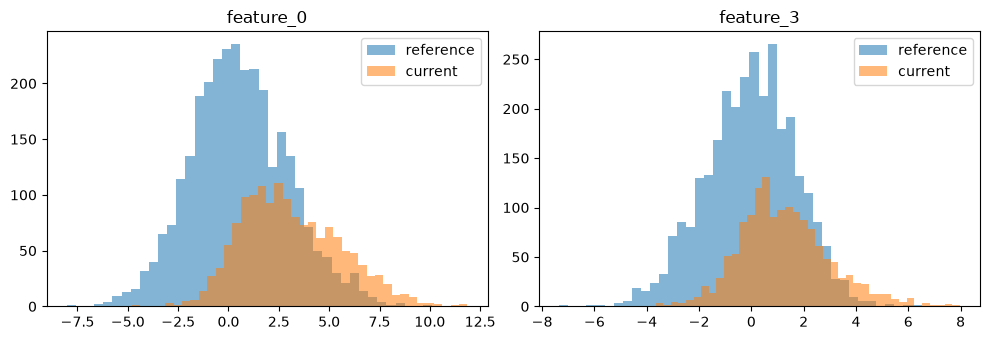

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col in zip(axes, DRIFTED_FEATURES):
    ax.hist(reference_df[col], bins=40, alpha=0.55, label="reference")
    ax.hist(current_df[col], bins=40, alpha=0.55, label="current")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [52]:
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset
from evidently.metrics import ColumnSummaryMetric

summary_metrics = [ColumnSummaryMetric(column_name=c) for c in FEATURE_NAMES]


report = Report(metrics=[DataDriftPreset(stattest="ks", stattest_threshold=0.05), *summary_metrics])
report.run(
    reference_data=reference_df[FEATURE_NAMES],
    current_data=current_df[FEATURE_NAMES],
)

report.save_html(str(ARTIFACTS / "drift_report.html"))
print("HTML-Report gespeichert:", (ARTIFACTS / "drift_report.html").resolve())

HTML-Report gespeichert: /Users/grigo/gits/seminars/gfu/mlops/mlops-professional/lab3_artifacts/drift_report.html


In [ ]:

ws_report = Report(metrics=[DataDriftPreset(stattest="wasserstein", stattest_threshold=0.1)])
ws_report.run(
    reference_data=reference_df[FEATURE_NAMES],
    current_data=current_df[FEATURE_NAMES],
)
ws_report.save_html(str(ARTIFACTS / "drift_wsreport.html"))

ws_dataset = next(
    m for m in ws_report.as_dict()["metrics"] if m["metric"] == "DatasetDriftMetric"
)["result"]
print("Wasserstein-Report gespeichert:", (ARTIFACTS / "drift_wsreport.html").resolve())
print(f"  Dataset-Drift erkannt:        {bool(ws_dataset['dataset_drift'])}")
print(f"  Anteil gedrifteter Features:  {ws_dataset['share_of_drifted_columns']:.0%}")

Wasserstein-Report gespeichert: /Users/grigo/gits/seminars/gfu/mlops/mlops-professional/lab3_artifacts/drift_wsreport.html
  Dataset-Drift erkannt:        True
  Anteil gedrifteter Features:  88%
